In [111]:
#pip install ydata-profiling 
#!pip install --upgrade --force-reinstall typing_extensions typeguard
##########################################################################"pour explorer le dataset plus en profondeur

#!pip install sweetviz il fait pareil

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import requests
import pandas as pd
import streamlit as st


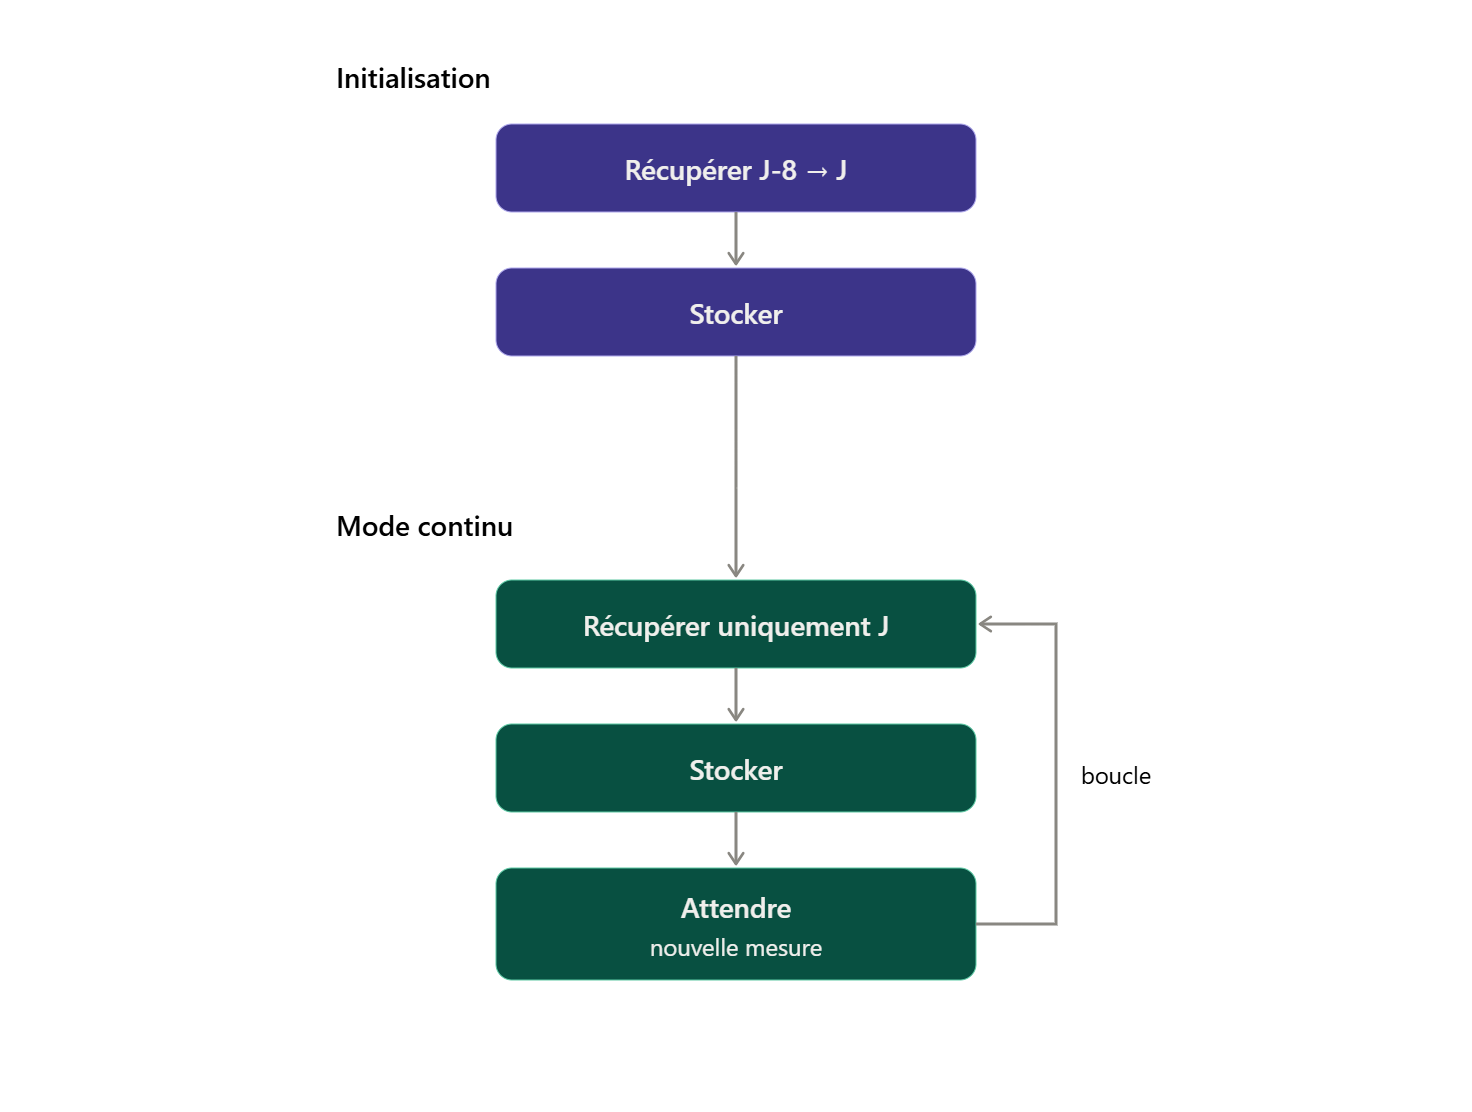

In [87]:
def air_quality(ville,token):
    url = f"https://api.waqi.info/feed/{ville}/?token={token}"
    try:
        response = requests.get(url)
        "vérifie la réussite de la requête"
        response.raise_for_status()
        dat= response.json()
        if dat["status"] == "ok":
            details= dat["data"]
            idx = details["idx"]
            aqi = details["aqi"]
            station = details["city"]["geo"]
            time = details["time"]
            print(f"time {time["s"]}")
            print(f"station {station}")
            print(f"indice aqi: {aqi}")
            if aqi <= 50:
                    print("Qualité de l'air : Excellente")
            elif aqi <= 100:
                print("Qualité de l'air : Modérée")
            elif aqi <= 150:
                print(
                     "Qualité de l'air : Malsaine pour les groupes sensibles"
                )
            else:
                print("Qualité de l'air : Mauvaise / Dangereuse")
            polluants = details.get("iaqi", {})


        # Récupération optionnelle des particules fines PM2.5 si disponibles
            if "pm25" in polluants:
                print(f" Particules PM2.5 : {polluants['pm25']['v']} µg/m³")
    except requests.exceptions.RequestException as e:
        print(f"💥 Erreur lors de la requête : {e}")
            
            
    
MON_TOKEN = st.secrets["WQAI_token"]
VILLE_CIBLE = "paris"

In [89]:
air_quality(VILLE_CIBLE,MON_TOKEN)

time 2026-09-25 12:00:00
station [48.856614, 2.3522219]
indice aqi: 43
Qualité de l'air : Excellente
 Particules PM2.5 : 43 µg/m³


In [90]:
import json
import requests

# 1. Coordonnées GPS qui encadrent toute l'Île-de-France (Sud-Ouest au Nord-Est)
IDF_BOUNDS = "48.1200,1.4000,49.2500,3.6000"

# 2. Votre clé API
token = st.secrets["WQAI_token"]  # Mettez votre jeton à la place

# 3. URL de l'API géographique pour obtenir la carte des stations et non pour une seule ville

url = (
    f"https://api.waqi.info/v2/map/bounds/" # Pour toute l'ile de france
    f"?latlng={IDF_BOUNDS}&token={token}"
)

try:
    response = requests.get(url)
    response.raise_for_status()
    dat = response.json()

    if dat["status"] == "ok":
        data = dat["data"]
        stations = data

        print(
            f"✅ Succès ! {len(stations)} stations trouvées en Île-de-France.\n"
        )

        # Affichage du JSON brut complet des 2 premières stations pour que vous voyiez la structure
        print("--- APERÇU DE LA STRUCTURE DU JSON ---")
        print(json.dumps(stations[:2], indent=4, ensure_ascii=False))
        print("---------------------------------------\n")

        # Extraction propre sous forme de liste 
        quality_of_air = []
        print("📍 LISTE COMPLÈTE DES STATIONS ET ID EN IDF :")
        for station in stations:
            uid = station["uid"]  # ID Unique pour vos requêtes futures
            nom = station["station"]["name"]
            aqi = station["aqi"]  # AQI en temps réel sur ce capteur
            lat = station["lat"]
            lon = station["lon"]
            time = station["station"]["time"]
            quality_of_air.append({"uid":uid,"nom":nom,"aqi":aqi,"lat":lat,"lon":lon,"time":time})

            print(f" • [ID: @{uid}] {nom} -> AQI actuel : {aqi}")
        

    else:
        print(f"⚠️ Erreur de l'API : {dat['data']}")
    quality_of_air = pd.DataFrame(quality_of_air)

except requests.exceptions.RequestException as e:
    print(f"💥 Erreur lors de la requête : {e}")


✅ Succès ! 34 stations trouvées en Île-de-France.

--- APERÇU DE LA STRUCTURE DU JSON ---
[
    {
        "lat": 49.1003,
        "lon": 2.34378,
        "uid": 5963,
        "aqi": "39",
        "station": {
            "name": "Zone Rurale Nord - Saint-martin-du-tertre, Paris",
            "time": "2026-09-25T20:00:00+09:00"
        }
    },
    {
        "lat": 49.0631,
        "lon": 1.8664,
        "uid": 3106,
        "aqi": "27",
        "station": {
            "name": "Zone Rurale Nord-ouest - Fremainville, Paris",
            "time": "2026-09-25T21:00:00+09:00"
        }
    }
]
---------------------------------------

📍 LISTE COMPLÈTE DES STATIONS ET ID EN IDF :
 • [ID: @5963] Zone Rurale Nord - Saint-martin-du-tertre, Paris -> AQI actuel : 39
 • [ID: @3106] Zone Rurale Nord-ouest - Fremainville, Paris -> AQI actuel : 27
 • [ID: @-472318] rue de Gometz -> AQI actuel : 9
 • [ID: @3088] Boulevard Peripherique Est, Paris -> AQI actuel : 43
 • [ID: @3085] Gennevilliers, Paris ->

In [91]:
quality_of_air

,uid,nom,aqi,lat,lon,time
0,5963,"Zone Rurale Nord - Saint-martin-du-tertre, Paris",39,49.100300,2.343780,2026-09-25T20:00:00+09:00
1,3106,"Zone Rurale Nord-ouest - Fremainville, Paris",27,49.063100,1.866400,2026-09-25T21:00:00+09:00
2,-472318,rue de Gometz,9,48.686688,2.145157,2026-09-25T13:29:58Z
3,3088,"Boulevard Peripherique Est, Paris",43,48.838600,2.412780,2026-09-25T20:00:00+09:00
4,3085,"Gennevilliers, Paris",48,48.930200,2.294210,2026-09-25T20:00:00+09:00
5,3099,"Bobigny, Paris",39,48.902400,2.452610,2026-09-25T21:00:00+09:00
6,3093,"Lognes, Paris",40,48.840300,2.634630,2026-09-25T20:00:00+09:00
7,6937,"Paris Stade Lenglen, Paris",24,48.830300,2.269720,2026-09-25T21:00:00+09:00
8,-476482,Le Cat Etoiles,15,48.601996,1.692400,2026-09-25T13:21:41Z
9,-1454125,Rue Adrien Damalix,4,48.820923,2.421895,2026-09-25T13:29:59Z


In [92]:
quality_of_air["time"] = pd.to_datetime(quality_of_air["time"],utc=True).dt.tz_convert('Europe/Paris')# pour l'harmonisation des fuseaux horaires

In [93]:
quality_of_air

,uid,nom,aqi,lat,lon,time
0,5963,"Zone Rurale Nord - Saint-martin-du-tertre, Paris",39,49.100300,2.343780,2026-09-25 13:00:00+02:00
1,3106,"Zone Rurale Nord-ouest - Fremainville, Paris",27,49.063100,1.866400,2026-09-25 14:00:00+02:00
2,-472318,rue de Gometz,9,48.686688,2.145157,2026-09-25 15:29:58+02:00
3,3088,"Boulevard Peripherique Est, Paris",43,48.838600,2.412780,2026-09-25 13:00:00+02:00
4,3085,"Gennevilliers, Paris",48,48.930200,2.294210,2026-09-25 13:00:00+02:00
5,3099,"Bobigny, Paris",39,48.902400,2.452610,2026-09-25 14:00:00+02:00
6,3093,"Lognes, Paris",40,48.840300,2.634630,2026-09-25 13:00:00+02:00
7,6937,"Paris Stade Lenglen, Paris",24,48.830300,2.269720,2026-09-25 14:00:00+02:00
8,-476482,Le Cat Etoiles,15,48.601996,1.692400,2026-09-25 15:21:41+02:00
9,-1454125,Rue Adrien Damalix,4,48.820923,2.421895,2026-09-25 15:29:59+02:00


In [95]:
import pandas as pd
import requests

# 1. Liste de tes capteurs extraite de tes données
capteurs = [
    {
        "id": "3106",
        "nom": "Zone Rurale Nord-ouest - Fremainville",
        "lat": 49.063100,
        "lon": 1.866400,
    },
    {"id": "13085", "nom": "Gennevilliers", "lat": 48.930200, "lon": 2.294210},
    {
        "id": "23095",
        "nom": "Route Nationale 6 - Melun",
        "lat": 48.528200,
        "lon": 2.653820,
    },
    {"id": "33102", "nom": "Nogent-sur-marne", "lat": 48.840800, "lon": 2.484400},
    {"id": "43099", "nom": "Bobigny", "lat": 48.902400, "lon": 2.452610},
    {
        "id": "5-2218252",
        "nom": "Boulevard de Denain",
        "lat": 48.879569,
        "lon": 2.354100,
    },
    {
        "id": "63083",
        "nom": "Foret De Fontainebleau",
        "lat": 48.354500,
        "lon": 2.645360,
    },
    {
        "id": "712763",
        "nom": "Paris 1er Les Halles",
        "lat": 48.862100,
        "lon": 2.344620,
    },
    {
        "id": "85963",
        "nom": "Saint-martin-du-tertre",
        "lat": 49.100300,
        "lon": 2.343780,
    },
    {
        "id": "9-1454125",
        "nom": "Rue Adrien Damalix",
        "lat": 48.820923,
        "lon": 2.421895,
    },
    {
        "id": "103094",
        "nom": "Rd934 Coulommiers",
        "lat": 48.805600,
        "lon": 3.084440,
    },
    {"id": "115722", "nom": "Paris", "lat": 48.856614, "lon": 2.352222},
    {"id": "123082", "nom": "Paris 18eme", "lat": 48.891700, "lon": 2.345630},
    {"id": "133097", "nom": "La Defense", "lat": 48.891300, "lon": 2.240640},
    {
        "id": "143091",
        "nom": "Place Victor Basch",
        "lat": 48.827700,
        "lon": 2.326700,
    },
    {"id": "153093", "nom": "Lognes", "lat": 48.840300, "lon": 2.634630},
    {
        "id": "16-472318",
        "nom": "rue de Gometz",
        "lat": 48.686688,
        "lon": 2.145157,
    },
    {"id": "173096", "nom": "Bois Herpin", "lat": 48.363500, "lon": 2.235390},
    {"id": "1811940", "nom": "Fulbert Chartres", "lat": 48.444210, "lon": 1.510230},
    {
        "id": "193092",
        "nom": "Place De Lopera Paris",
        "lat": 48.870400,
        "lon": 2.332410,
    },
    {
        "id": "203098",
        "nom": "Autoroute A1 Saint-denis",
        "lat": 48.925100,
        "lon": 2.356540,
    },
    {
        "id": "21-476482",
        "nom": "Le Cat Etoiles",
        "lat": 48.601996,
        "lon": 1.692400,
    },
    {"id": "2211944", "nom": "Sens", "lat": 48.200436, "lon": 3.277300},
    {
        "id": "233101",
        "nom": "Tremblay-en-france",
        "lat": 48.955700,
        "lon": 2.574410,
    },
    {
        "id": "243086",
        "nom": "Champs Elysees",
        "lat": 48.868600,
        "lon": 2.311660,
    },
    {"id": "253105", "nom": "Gonesse", "lat": 48.990800, "lon": 2.444610},
    {"id": "26-564007", "nom": "Rue Gambetta", "lat": 48.343605, "lon": 2.708535},
    {"id": "27-422221", "nom": "Arcueil", "lat": 48.810499, "lon": 2.334289},
    {
        "id": "283088",
        "nom": "Boulevard Peripherique Est",
        "lat": 48.838600,
        "lon": 2.412780,
    },
    {"id": "293103", "nom": "Vitry-sur-seine", "lat": 48.775900, "lon": 2.375770},
    {
        "id": "306937",
        "nom": "Paris Stade Lenglen",
        "lat": 48.830300,
        "lon": 2.269720,
    },
    {"id": "3112762", "nom": "Rambouillet", "lat": 48.633700, "lon": 1.830430},
    {"id": "323104", "nom": "Cergy-pontoise", "lat": 49.045900, "lon": 2.041040},
    {"id": "3314715", "nom": "Rn20 Montlhery", "lat": 48.640930, "lon": 2.268720},
]

# 2. Fonction pour récupérer les 8 derniers jours d'historique
df_historique_total = pd.DataFrame()

print("Début du téléchargement...")

for c in capteurs:
    
    url = (
    f"https://air-quality-api.open-meteo.com/v1/air-quality?"
    f"latitude={c['lat']}&longitude={c['lon']}&"
    f"hourly=pm10,pm2_5,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide,european_aqi,birch_pollen&"
    f"temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,precipitation&" #Api pour récupérer les données 
    f"past_days=8"
    )

    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()
        df_temp = pd.DataFrame(data["hourly"])
        df_temp["capteur_id"] = c["id"]
        df_temp["capteur_nom"] = c["nom"]
        df_temp["latitude"] = c["lat"]
        df_temp["longitude"] = c["lon"]

        df_historique_total = pd.concat(
            [df_historique_total, df_temp], ignore_index=True
        )
        print(f"✅ {c['nom']} traité.")
    else:
        print(f"❌ Erreur pour {c['nom']}")

# 3. Export du résultat sous forme de fichier CSV
"""df_historique_total.to_csv("historique_qualite_air_8jours.csv", index=False)
print(
    "\n Terminé ! Le fichier 'historique_qualite_air_8jours.csv' a été généré."
)"""

Début du téléchargement...
✅ Zone Rurale Nord-ouest - Fremainville traité.
✅ Gennevilliers traité.
✅ Route Nationale 6 - Melun traité.
✅ Nogent-sur-marne traité.
✅ Bobigny traité.
✅ Boulevard de Denain traité.
✅ Foret De Fontainebleau traité.
✅ Paris 1er Les Halles traité.
✅ Saint-martin-du-tertre traité.
✅ Rue Adrien Damalix traité.
✅ Rd934 Coulommiers traité.
✅ Paris traité.
✅ Paris 18eme traité.
✅ La Defense traité.
✅ Place Victor Basch traité.
✅ Lognes traité.
✅ rue de Gometz traité.
✅ Bois Herpin traité.
✅ Fulbert Chartres traité.
✅ Place De Lopera Paris traité.
✅ Autoroute A1 Saint-denis traité.
✅ Le Cat Etoiles traité.
✅ Sens traité.
✅ Tremblay-en-france traité.
✅ Champs Elysees traité.
✅ Gonesse traité.
✅ Rue Gambetta traité.
✅ Arcueil traité.
✅ Boulevard Peripherique Est traité.
✅ Vitry-sur-seine traité.
✅ Paris Stade Lenglen traité.
✅ Rambouillet traité.
✅ Cergy-pontoise traité.
✅ Rn20 Montlhery traité.


'df_historique_total.to_csv("historique_qualite_air_8jours.csv", index=False)\nprint(\n    "\n Terminé ! Le fichier \'historique_qualite_air_8jours.csv\' a été généré."\n)'

In [99]:
df_historique_total.describe()

,pm10,pm2_5,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide,european_aqi,birch_pollen,latitude,longitude
count,10608.000000,10608.000000,10608.000000,10608.000000,10608.000000,10608.000000,10608.000000,9826.0,10608.000000,10608.000000
mean,13.109408,8.226735,12.973445,55.834549,0.943392,209.625575,31.978884,0.0,48.771240,2.351966
std,4.116400,3.540569,11.154057,20.877901,0.701550,46.752710,8.505563,0.0,0.217289,0.330292
min,3.900000,2.600000,0.300000,2.000000,0.000000,122.000000,14.000000,0.0,48.200436,1.510230
25%,10.100000,5.900000,4.700000,41.000000,0.400000,182.000000,25.000000,0.0,48.640930,2.268720
50%,12.500000,7.300000,9.500000,53.000000,0.800000,201.000000,31.000000,0.0,48.839450,2.345125
75%,15.700000,9.600000,17.900000,72.000000,1.300000,224.000000,37.000000,0.0,48.891700,2.452610
max,29.500000,23.900000,58.000000,128.000000,4.700000,522.000000,64.000000,0.0,49.100300,3.277300


In [101]:
df_historique_total["time"]=pd.to_datetime(df_historique_total["time"],utc=True).dt.tz_convert('Europe/Paris')
# pour l'harmonisation des fuseaux horaires

In [102]:
df_historique_total["time"]=df_historique_total["time"].dt.strftime("%Y-%m-%d %H:%M:%S") # conversion de la date et de l'heure 

In [103]:
df_historique_total 

,time,pm10,pm2_5,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide,european_aqi,birch_pollen,capteur_id,capteur_nom,latitude,longitude
0,2026-09-17 02:00:00,8.2,4.9,4.4,49.0,0.3,186.0,20,0.0,3106,Zone Rurale Nord-ouest - Fremainville,49.06310,1.86640
1,2026-09-17 03:00:00,8.1,4.6,3.8,49.0,0.2,187.0,18,0.0,3106,Zone Rurale Nord-ouest - Fremainville,49.06310,1.86640
2,2026-09-17 04:00:00,7.8,4.2,3.4,47.0,0.2,187.0,17,0.0,3106,Zone Rurale Nord-ouest - Fremainville,49.06310,1.86640
3,2026-09-17 05:00:00,7.7,4.1,3.1,47.0,0.2,186.0,16,0.0,3106,Zone Rurale Nord-ouest - Fremainville,49.06310,1.86640
4,2026-09-17 06:00:00,7.2,4.3,3.1,49.0,0.1,184.0,17,0.0,3106,Zone Rurale Nord-ouest - Fremainville,49.06310,1.86640
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10603,2026-09-29 21:00:00,16.6,14.8,39.2,38.0,1.5,217.0,48,NaN,3314715,Rn20 Montlhery,48.64093,2.26872
10604,2026-09-29 22:00:00,15.1,13.5,33.4,39.0,1.5,213.0,45,NaN,3314715,Rn20 Montlhery,48.64093,2.26872
10605,2026-09-29 23:00:00,13.7,12.2,28.0,41.0,1.5,209.0,42,NaN,3314715,Rn20 Montlhery,48.64093,2.26872
10606,2026-09-30 00:00:00,12.5,11.0,24.5,41.0,1.4,206.0,39,NaN,3314715,Rn20 Montlhery,48.64093,2.26872


# Exploration plus poussée

In [119]:
#n'a pas fonctionné, problème de dépendance
"""from ydata_profiling import ProfileReport

# Génère le rapport complet
profile = ProfileReport(
    df_historique_total,
    title="Analyse Qualité de l'Air & Météo",
    explorative=True,
)

profile.to_notebook_iframe()

# exporter le  en fichier HTML pour le rapport?
# profile.to_file("rapport_dataset.html")"""

'from ydata_profiling import ProfileReport\n\n# Génère le rapport complet\nprofile = ProfileReport(\n    df_historique_total,\n    title="Analyse Qualité de l\'Air & Météo",\n    explorative=True,\n)\n\nprofile.to_notebook_iframe()\n\n# exporter le  en fichier HTML pour le rapport?\n# profile.to_file("rapport_dataset.html")'

In [113]:
import sweetviz as sv

# Générer l'analyse
report = sv.analyze(df_historique_total)

# Sauvegarder et ouvrir le rapport dans ton navigateur
report.show_html("rapport_qualite_air.html")

                                             |                                             | [  0%]   00:00 ->…

Report rapport_qualite_air.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
